In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

np.random.seed(42) #Allows us to reproduce results as random numbers generated are the same

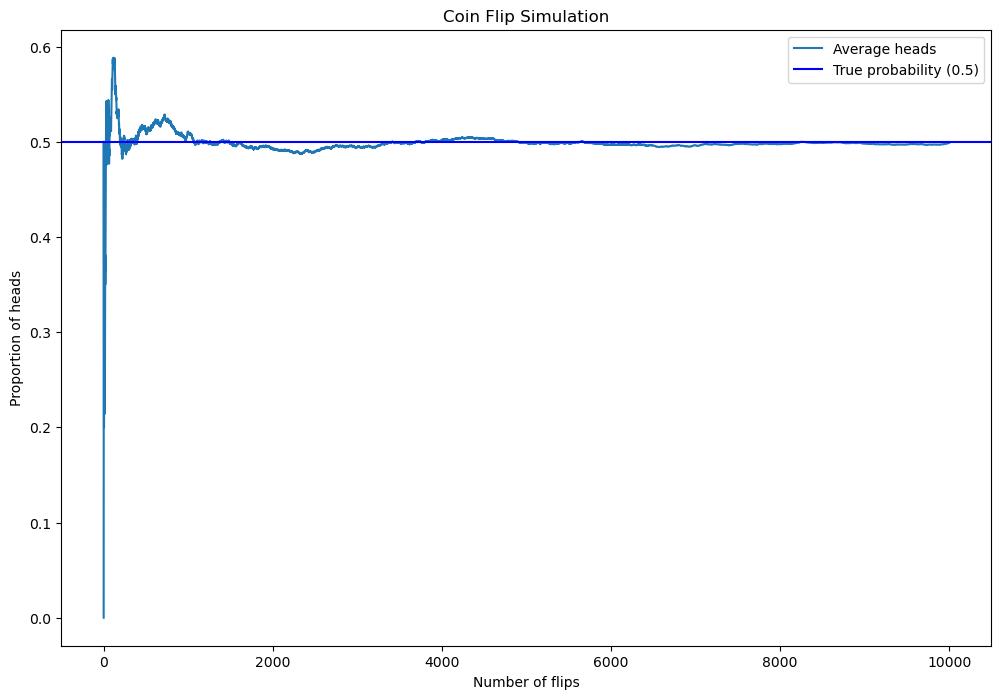

In [2]:
#SECTION 1: Simulation of Law of Large Numbers

# Example using flipping a fair coin n times and tracking its average
n=10000
flips=np.random.choice([0,1],size=n) # 0= tails, 1= heads
average=np.cumsum(flips)/np.arange(1,n+1)

plt.figure(figsize=(12,8))
plt.plot(average,label="Average heads")
plt.axhline(y=0.5,color="blue",label="True probability (0.5)")
plt.xlabel("Number of flips")
plt.ylabel("Proportion of heads")
plt.title("Coin Flip Simulation")
plt.legend()
plt.show()

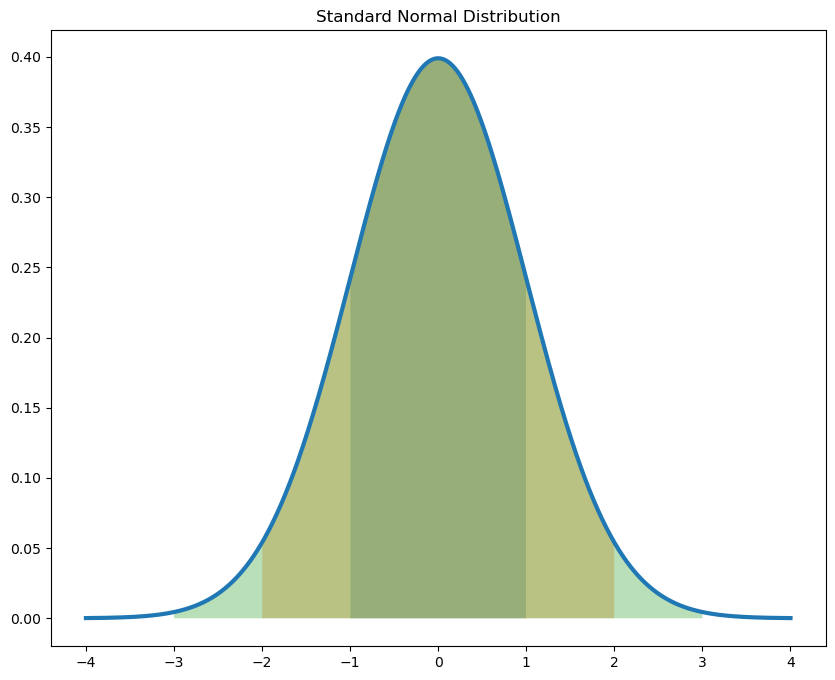

In [3]:
#SECTION 2: Distributions
# 2.1 Normal Distribution:
#Testing the 68-95-99.7 rule

x=np.linspace(-4,4,1000)
y=stats.norm.pdf(x,loc=0,scale=1) #loc = mean, scale = SD

plt.figure(figsize=(10,8))
plt.plot(x,y,linewidth=3)
plt.fill_between(x,y,where=(x>=-1)&(x<=1),alpha=0.33,label="Within 1 std dev (68%)")
plt.fill_between(x,y,where=(x>=-2)&(x<=2),alpha=0.33,label="Within 2 std dev (95%)")
plt.fill_between(x,y,where=(x>=-3)&(x<=3),alpha=0.33,label="Within 3 std dev (99.7%)")
plt.title("Standard Normal Distribution")
plt.show()



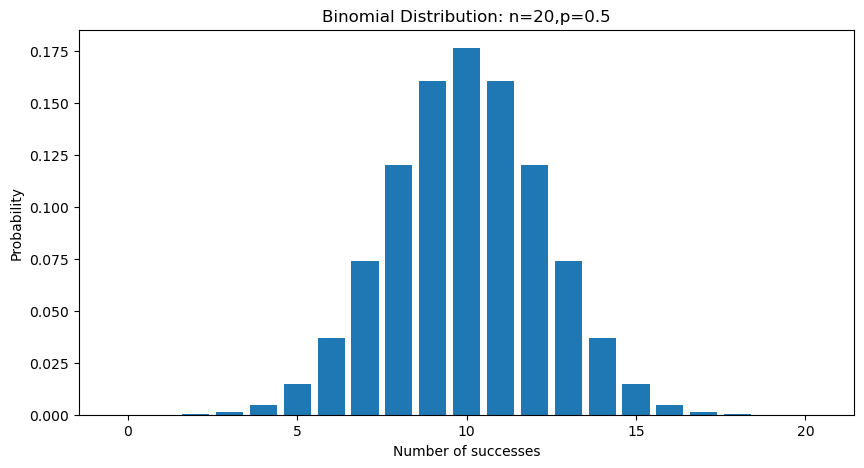

In [4]:
#2.2 Binomial Dist:

n=20 #trials
p=0.5
x=np.arange(0,n +1)
pmf= stats.binom.pmf(x, n=n,p=p)

plt.figure(figsize=(10,5))
plt.bar(x,pmf)
plt.title(f"Binomial Distribution: n={n},p={p}")
plt.xlabel("Number of successes")
plt.ylabel("Probability")
plt.show()

In [5]:
#SECTION 3: Connect to Financial Data

import yfinance as yf

tickers=['AAPL','MSFT','NVDA','META','JPM','GS','MS','BAC','BLK']
data=yf.download(tickers, start="2020-01-01", end="2026-01-01")
prices=data["Close"]
log_returns=np.log(prices/prices.shift(1)).dropna()
# log_returns.head()

[*********************100%***********************]  9 of 9 completed


In [6]:
aapl_returns=log_returns["AAPL"]
prob_positive = (aapl_returns>0).mean()
print(f"Probability of a positive AAPL day: {prob_positive:.2%}") # .x% gives to x decimal points 
print(f"Probability of a negative AAPL day: {1-prob_positive:.2%}")

Probability of a positive AAPL day: 53.15%
Probability of a negative AAPL day: 46.85%


In [7]:
#Apply to financial question: What's the probability f losing more than 3% in 1 day in AAPL

prob_large_loss =(aapl_returns < -0.03).mean()
print(f"Probability of losing more than 3% in a day: {prob_large_loss:.2%}")

#how many times did that happen over these 6 years
occurences= (aapl_returns<-0.03).sum()
print(f"Number of days that this actually happened: {occurences} out of {len(aapl_returns)} trading days")


Probability of losing more than 3% in a day: 5.64%
Number of days that this actually happened: 85 out of 1507 trading days


In [8]:
#SECTION 4: Descriptive Stats on Returns

stats_summary = log_returns.describe()
print(stats_summary)

Ticker         AAPL          BAC          BLK           GS          JPM  \
count   1507.000000  1507.000000  1507.000000  1507.000000  1507.000000   
mean       0.000877     0.000386     0.000590     0.000972     0.000658   
std        0.019994     0.021647     0.019441     0.020625     0.019734   
min       -0.137708    -0.167204    -0.146814    -0.135880    -0.162106   
25%       -0.008243    -0.009677    -0.008597    -0.009215    -0.008003   
50%        0.001139     0.000452     0.000977     0.000775     0.000976   
75%        0.011399     0.010721     0.009895     0.011638     0.009959   
max        0.142617     0.163786     0.126843     0.161951     0.165621   

Ticker         META           MS         MSFT         NVDA  
count   1507.000000  1507.000000  1507.000000  1507.000000  
mean       0.000765     0.000940     0.000766     0.002284  
std        0.027857     0.021909     0.018608     0.033330  
min       -0.306391    -0.169603    -0.159453    -0.203979  
25%       -0.011682

In [9]:
skewness= log_returns.skew()
kurtosis = log_returns.kurtosis()

print("Skewness:")
print(skewness)
print("\nKurtosis (excess):")
print(kurtosis)

#Skewness of perfect normal dist = 0. Negative skew = longer left tail = big losses happen more often than normal dist predicts
#Kurtosis measures weight of tails. Excess Kurt of perfect normal dist = 0. Positive kurt means extereme events of crashes and rallies
#happen more often than the norm dist predicts

#We see that forthe majority of the stocks, the skewness is negative and excess kurtosis is positive. This is leptokurtosis. Prove sthat models assuming normality of returns fail irl.

Skewness:
Ticker
AAPL    0.028950
BAC    -0.093507
BLK    -0.100159
GS     -0.070240
JPM    -0.072746
META   -1.075118
MS      0.071656
MSFT   -0.163083
NVDA    0.043994
dtype: float64

Kurtosis (excess):
Ticker
AAPL     6.467527
BAC     10.590041
BLK      8.637659
GS       9.557026
JPM     12.527597
META    22.167001
MS      12.229049
MSFT     7.875965
NVDA     4.070195
dtype: float64


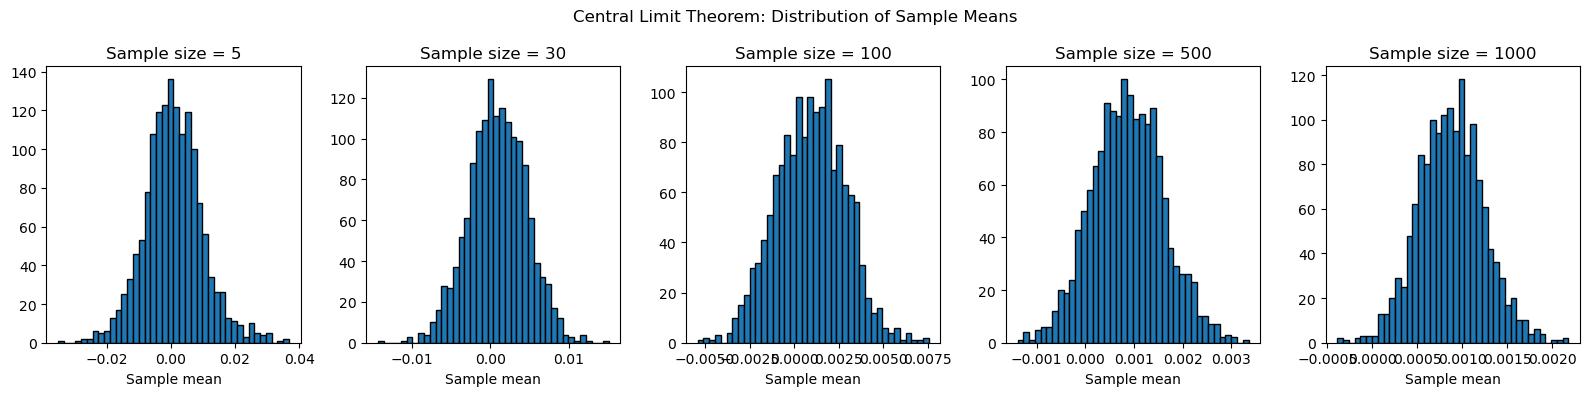

In [12]:
# SECTION 5: Central Limit Theorem
import matplotlib.pyplot as plt
sample_size = [5,30,100,500,1000]
fig,axes= plt.subplots(1,5,figsize=(16,4))

for i,n in enumerate(sample_size):
    sample_means= [aapl_returns.sample(n).mean() for _ in range(1500)]
    axes[i].hist(sample_means,bins=40,edgecolor="black")
    axes[i].set_title(f"Sample size = {n}")
    axes[i].set_xlabel("Sample mean")

plt.suptitle("Central Limit Theorem: Distribution of Sample Means")
plt.tight_layout()
plt.show()

In [ ]:
# Hypothesis Question: Are AAPL's returns actually normal?

aapl_returns = log_returns["AAPL"]
mu=appl_returns.mean()
sigma= 